Today's date: 2024-04-18
SUCCESS
JOWL8OlgQoA2ftAH56QPD0qfD2sGZ4z4+14qfgaX0WE=
Today's date: 2024-04-18
First Market:  1.227733344 R2 571m Rest 2024-04-18T01:47:00.000Z 35.00359
Total number of markets today 138
Today's date: 2024-04-18 Yesterday's date: 2024-04-17


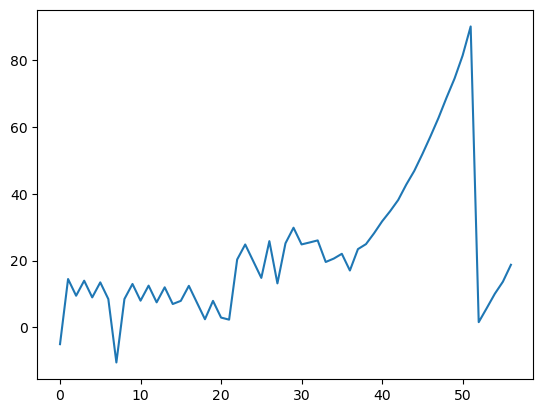

wins: 38, losses: 19, winRatio: 0.67
1.227733344
assess Muswellbrook Greyhound Racing race in 822.0 seconds
number of runners  7
realBalance 66.2
balance: 13.4, stake: 2.79, liability: 13.4, layPrice: 5.8, Selection name: Butterwick 
Number of Bets in Muswellbrook race 2: 0
Selection name: Butterwick layPrice: 6.0 ResultsStatus: SUCCESS
BSP: 5.8, stake: 2.79, Lay Price 6.0, Balance 13.4
result: CLOSED, LOSER, remainingRaces: 137
balance: 15.98075
nextMarketId: 1.227732081, nextMarketName R1 390m Mdn, nextMarketStartTime2024-04-18T01:55:00.000Z, nextTotalMatched 173.7, nextStartTimeDelay 349.0
0.34% return, 15.98 balance max, 15.98 balance min
1.227733344
assess Shepparton Greyhound Racing race in 345.0 seconds
number of runners  8
realBalance 68.83
balance: 15.98, stake: 1.68, liability: 15.98, layPrice: 10.5, Selection name: Demure 
Number of Bets in Shepparton race 1: 0
Selection name: Demure layPrice: 11.5 ResultsStatus: SUCCESS
BSP: 9.8, stake: 1.68, Lay Price 11.5, Balance 15.9807

C:\Users\Tristan\AppData\Local\Temp\ipykernel_6316\122424136.py:655: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(2, 1)


1.227733389
assess Shepparton Greyhound Racing race in 284.0 seconds
number of runners  8
realBalance 24.56
Error in market 1.227733389...111 races remaining today...reattempting in None seconds
1.227733389
assess Capalaba Greyhound Racing race in 470.0 seconds
number of runners  6
realBalance 39.38
balance: 11.25, stake: 2.39, liability: 11.25, layPrice: 5.7, Selection name: Regal Romeo 
Number of Bets in Capalaba race 9: 0
Selection name: Regal Romeo layPrice: 5.9 ResultsStatus: SUCCESS
BSP: 12.5, stake: 2.39, Lay Price 5.9, Balance 11.253000000000002
result: CLOSED, WINNER, remainingRaces: 110
balance: 5
nextMarketId: 1.227733394, nextMarketName R12 336m Gr5, nextMarketStartTime2024-04-18T04:42:00.000Z, nextTotalMatched 675.24, nextStartTimeDelay 171.0
-0.58% return, 31.69 balance max, 5.0 balance min
1.227732708
assess Muswellbrook Greyhound Racing race in 168.0 seconds
number of runners  8
realBalance 13.1
Balance 5. Too Low
Error in market 1.227732708...109 races remaining today.

KeyError: 'result'

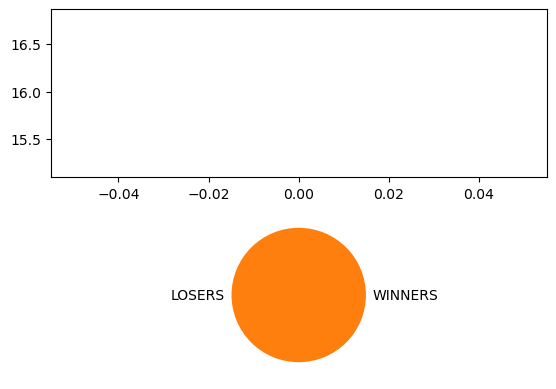

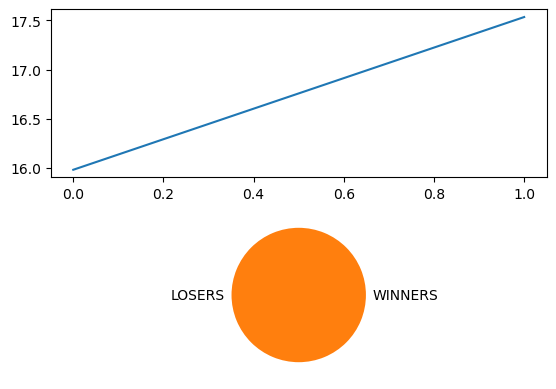

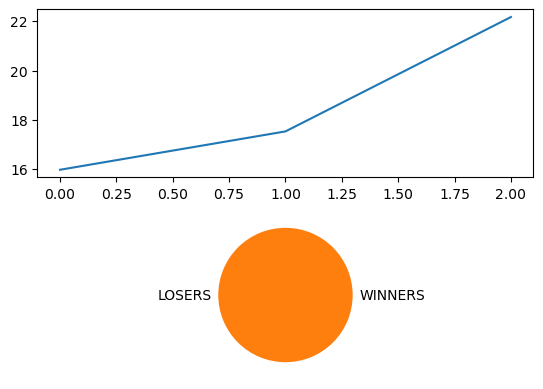

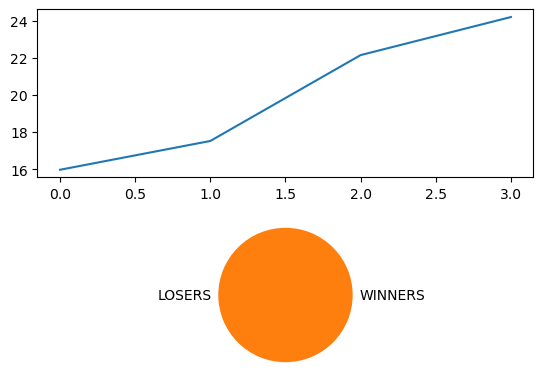

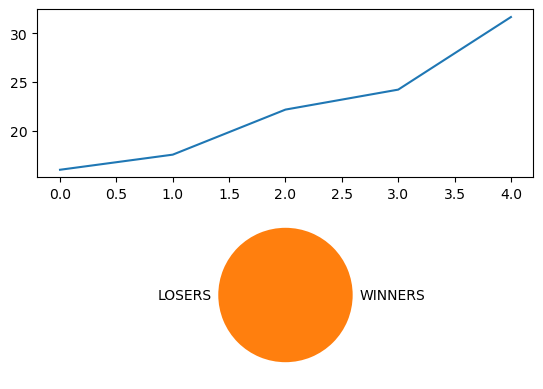

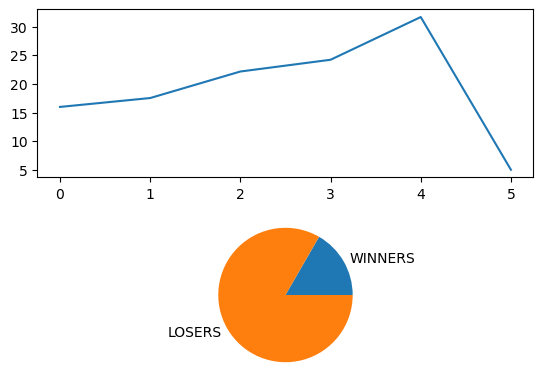

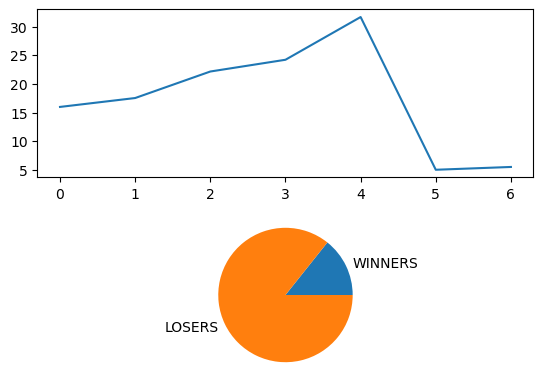

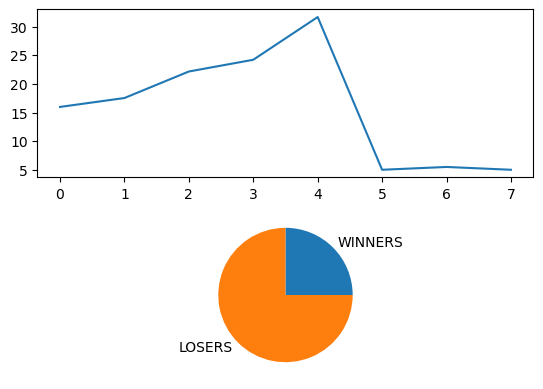

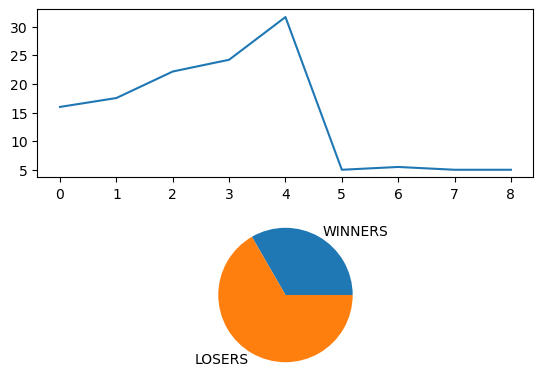

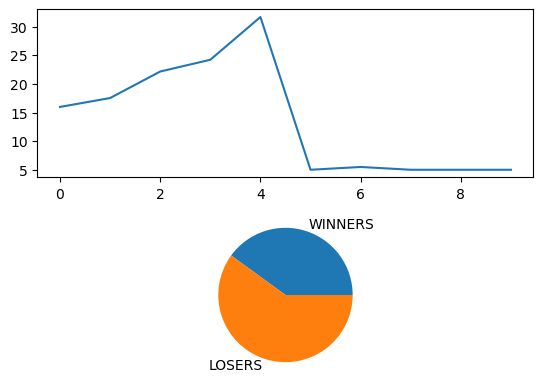

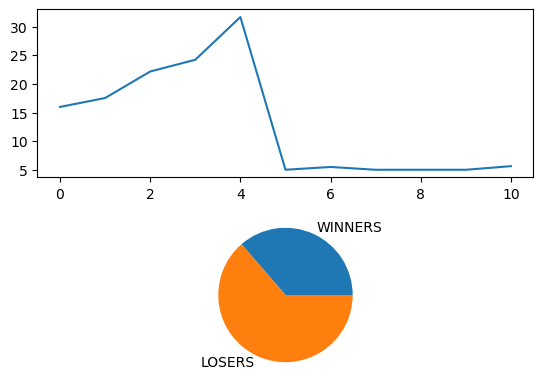

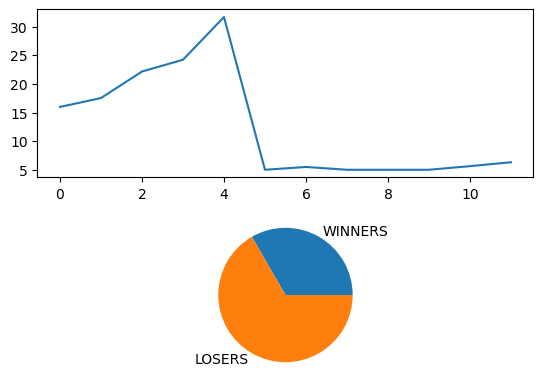

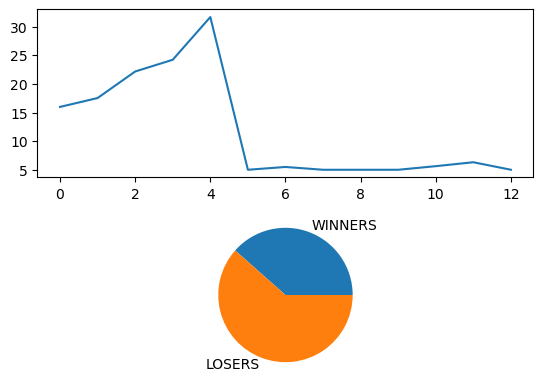

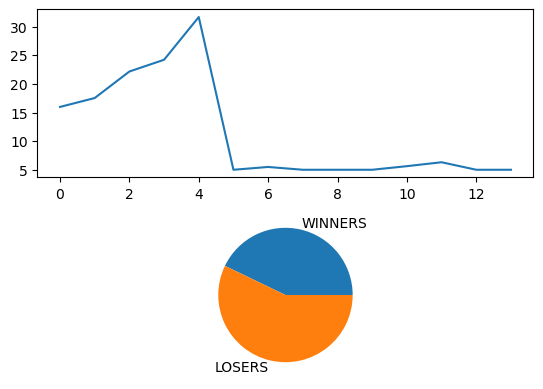

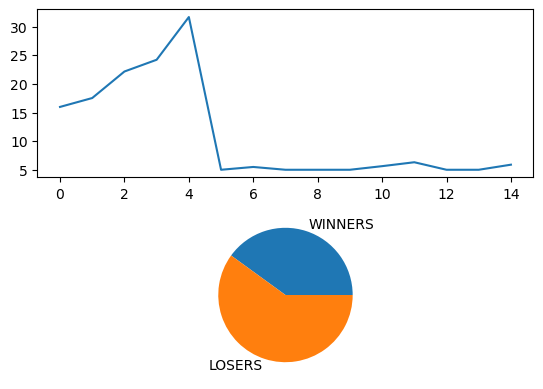

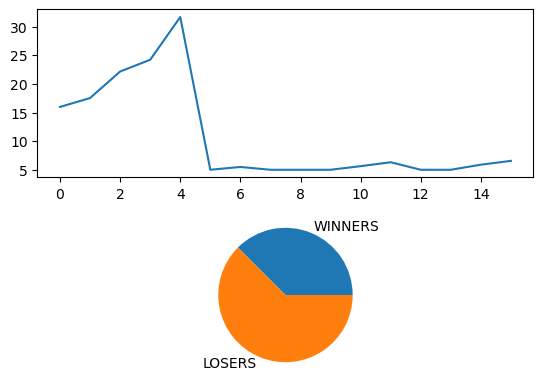

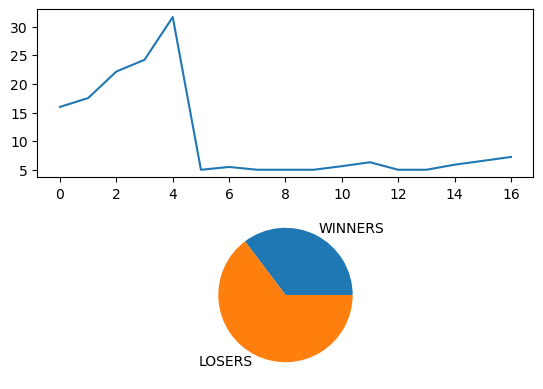

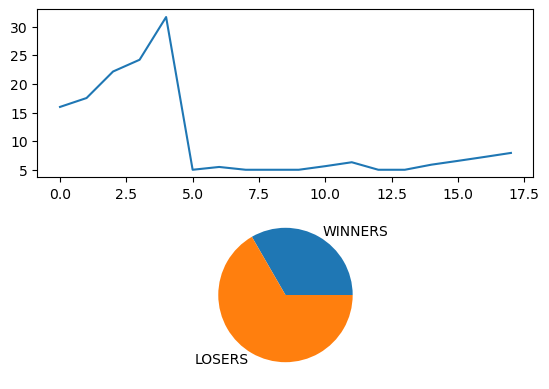

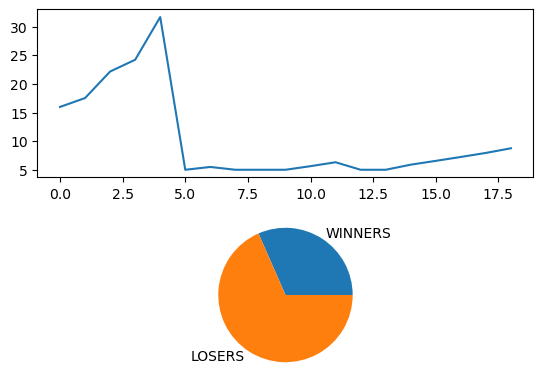

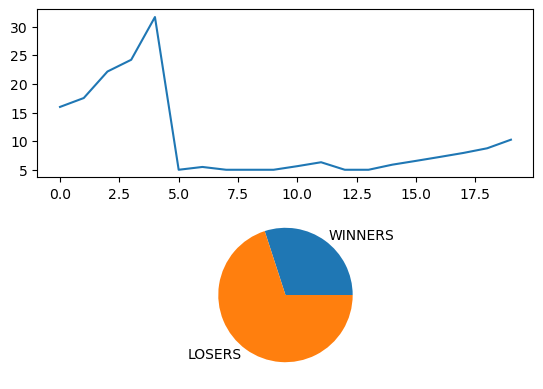

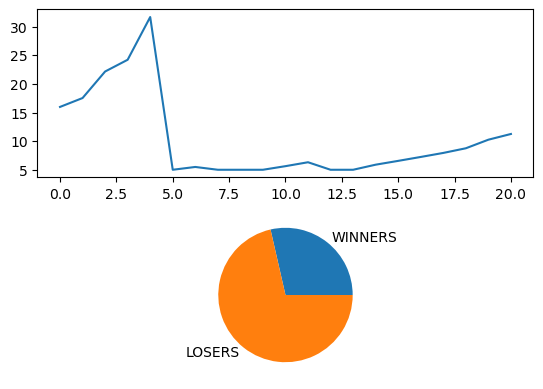

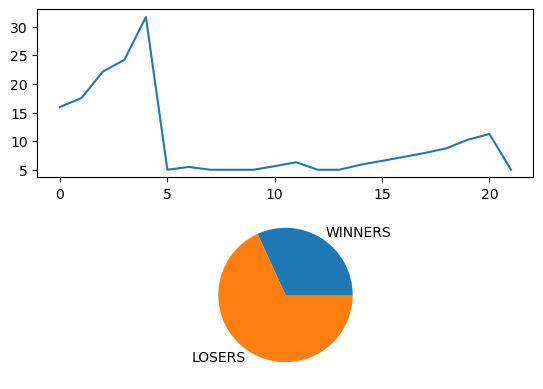

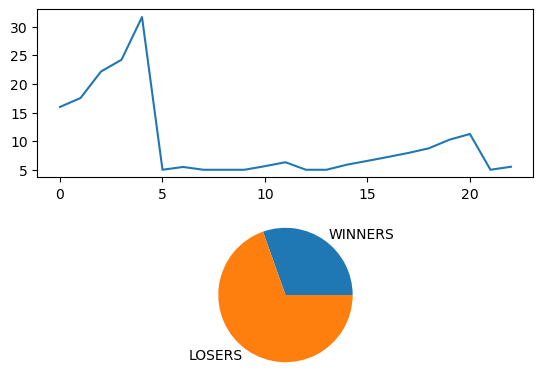

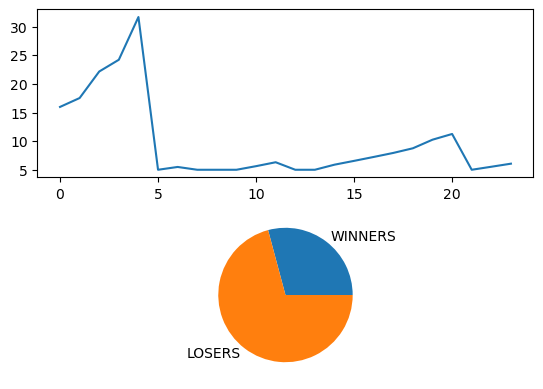

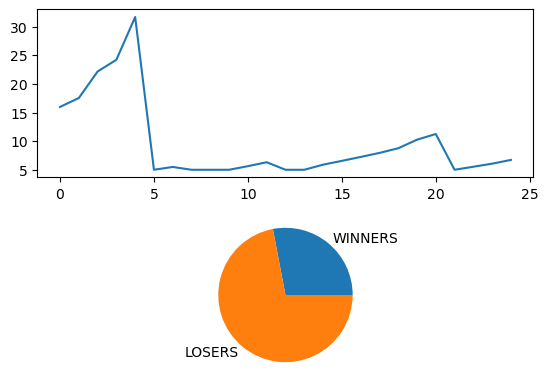

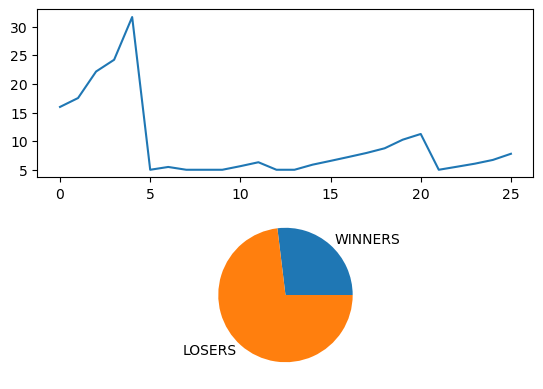

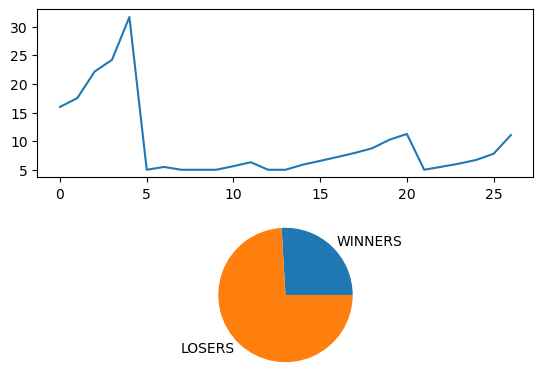

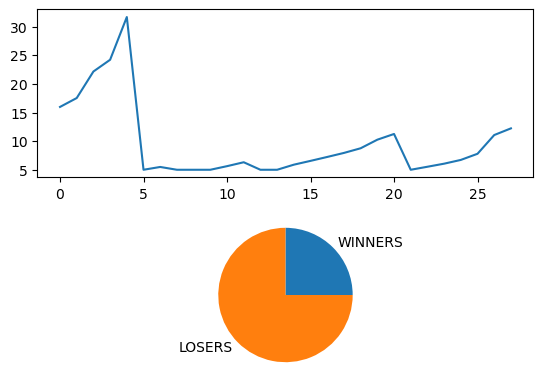

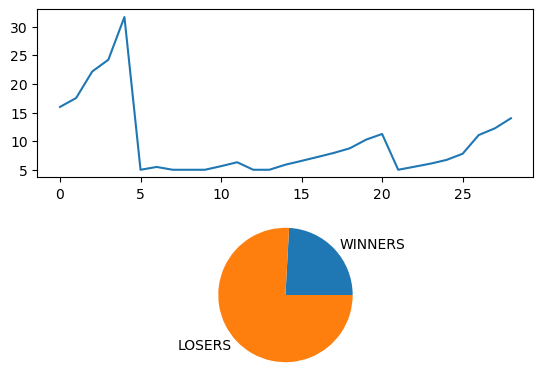

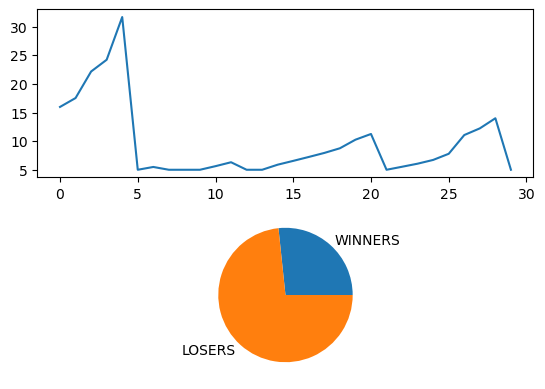

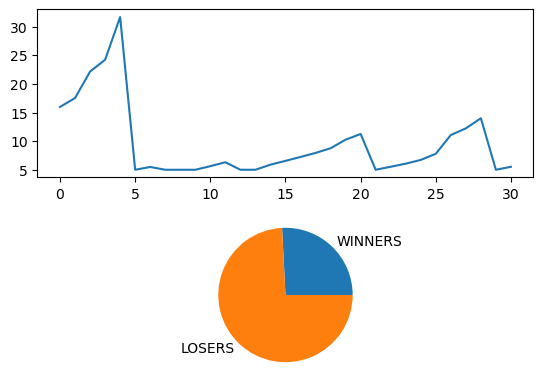

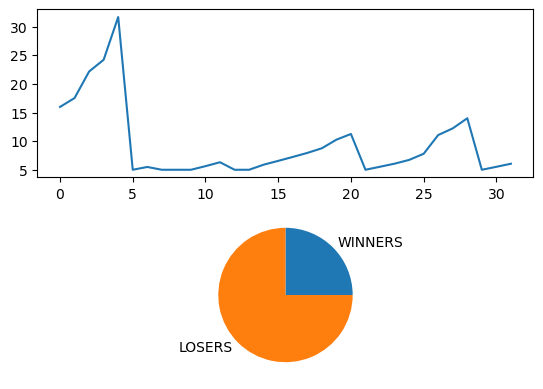

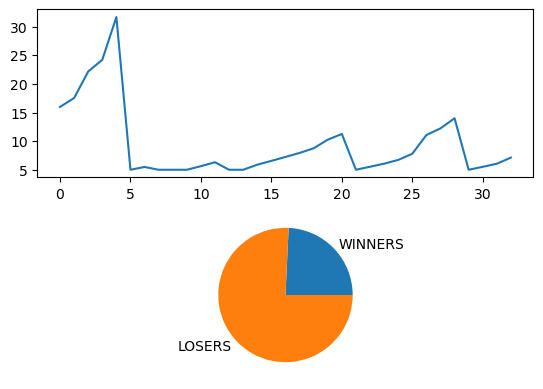

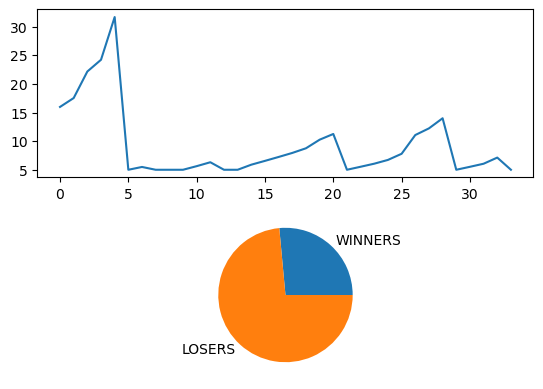

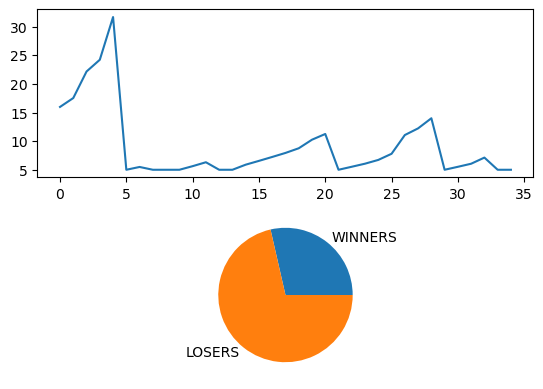

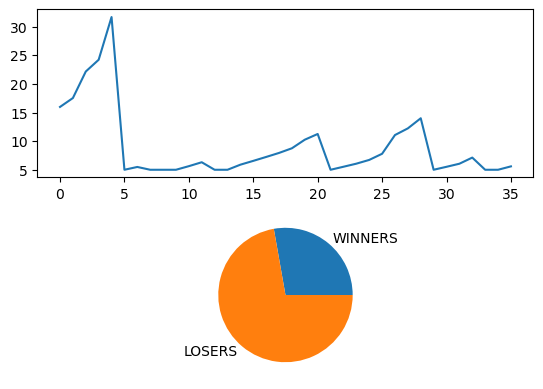

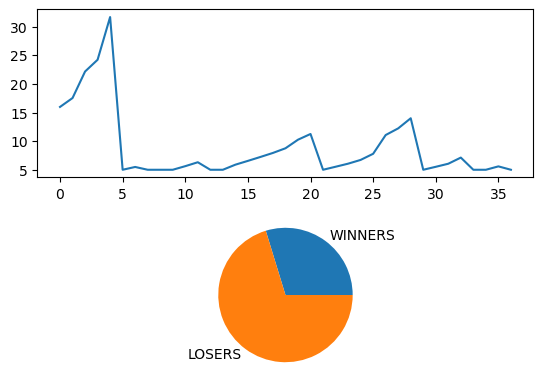

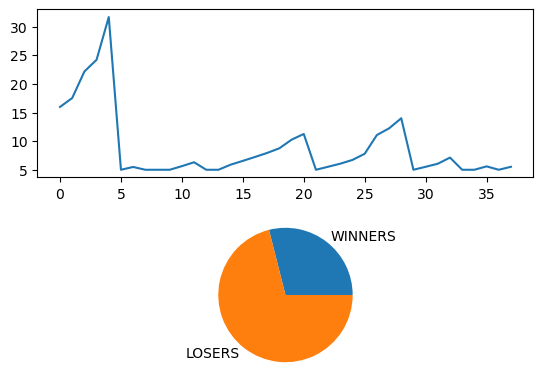

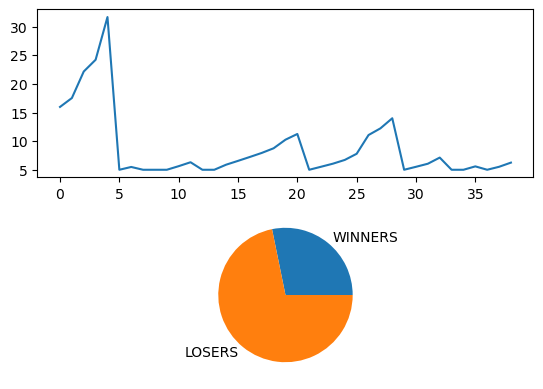

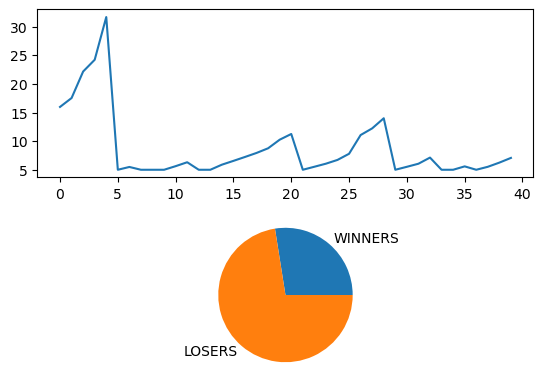

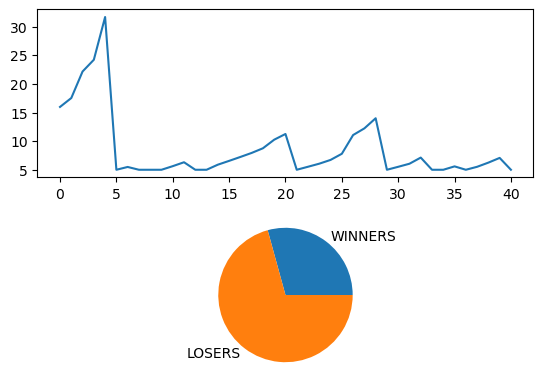

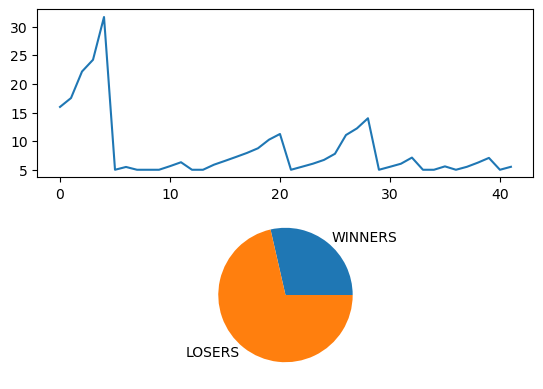

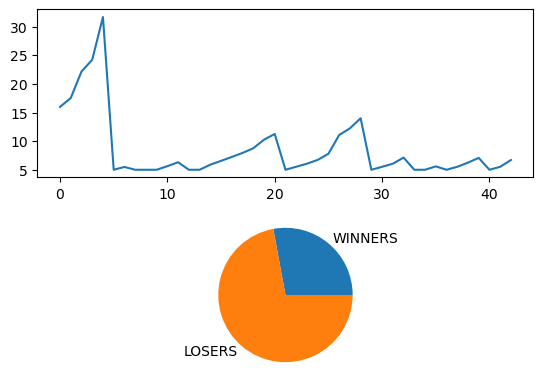

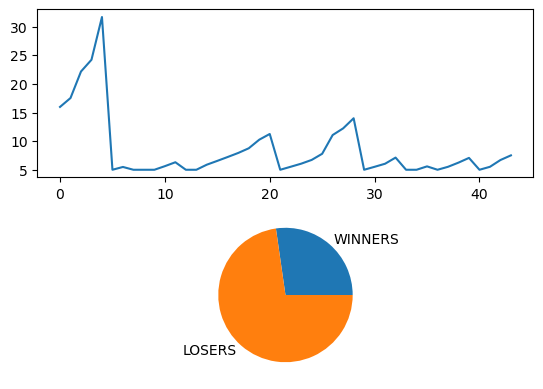

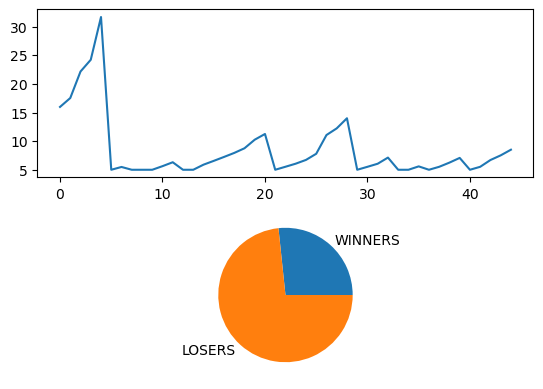

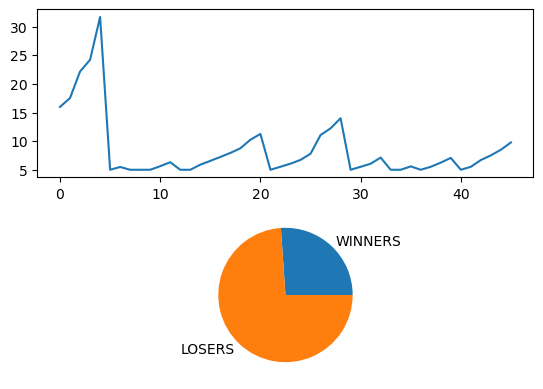

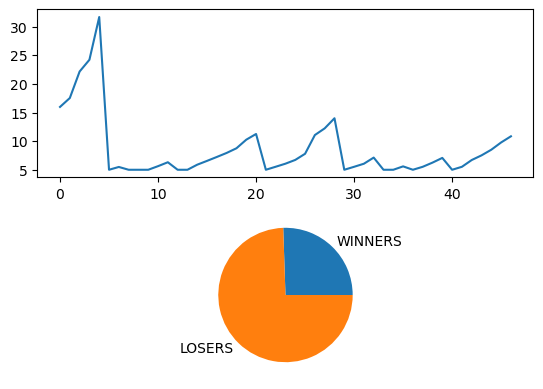

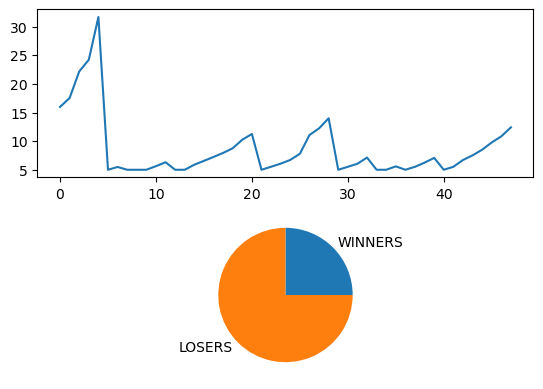

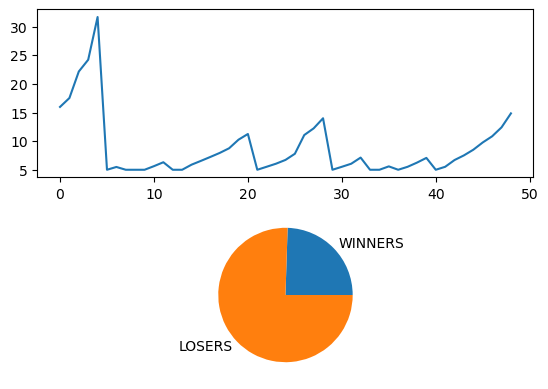

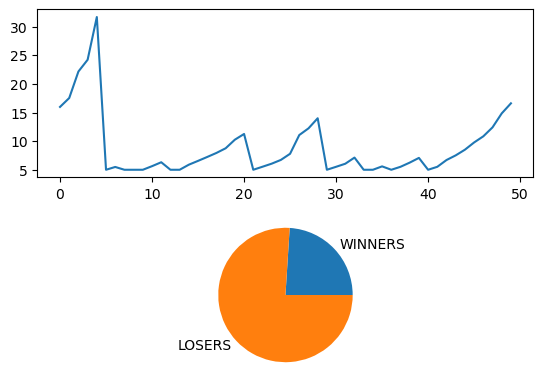

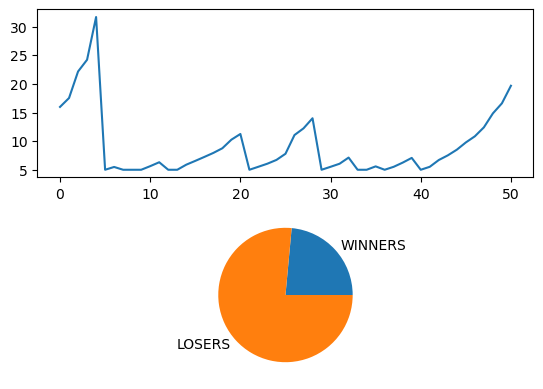

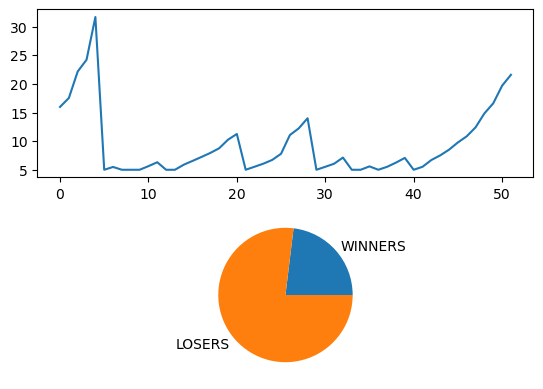

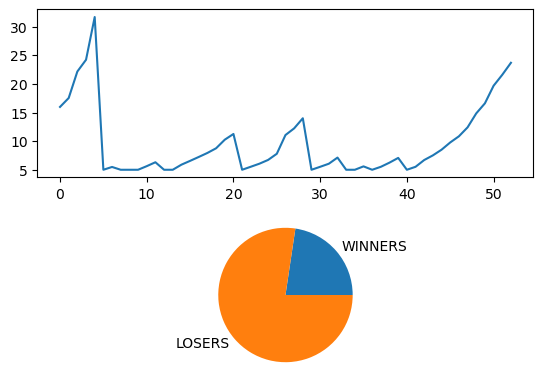

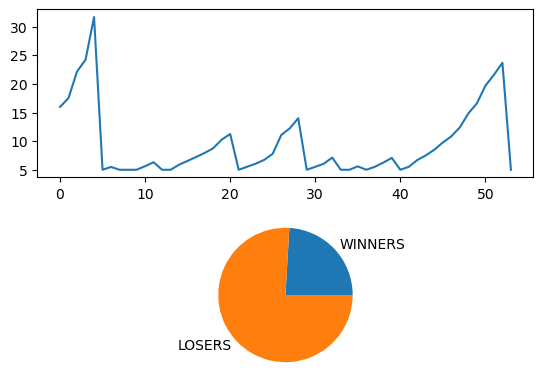

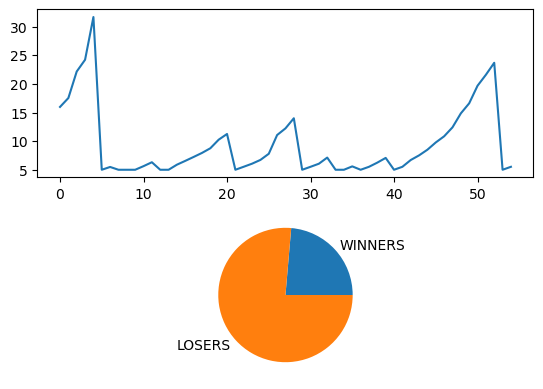

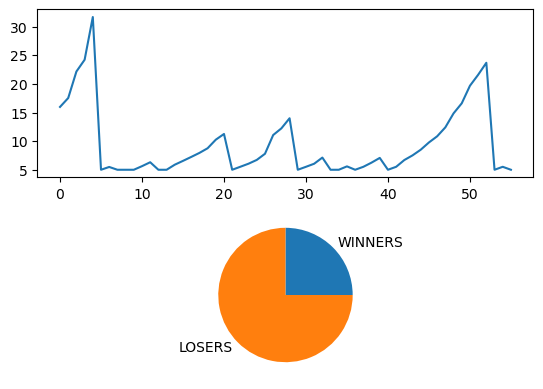

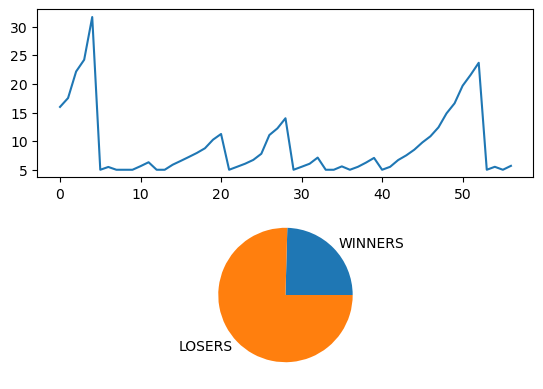

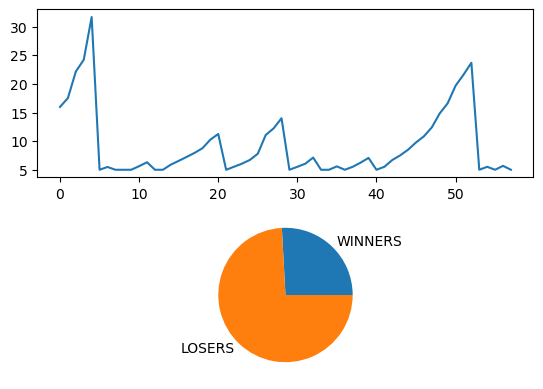

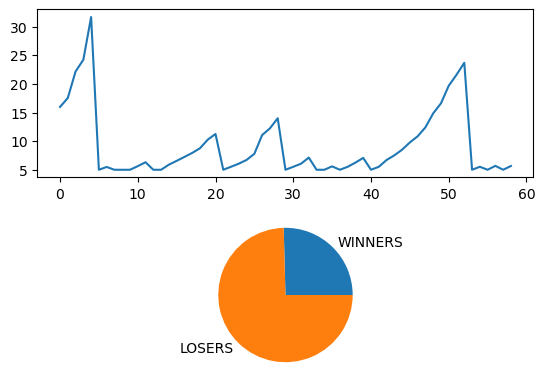

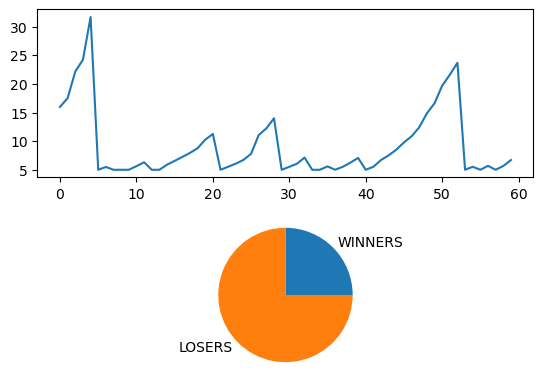

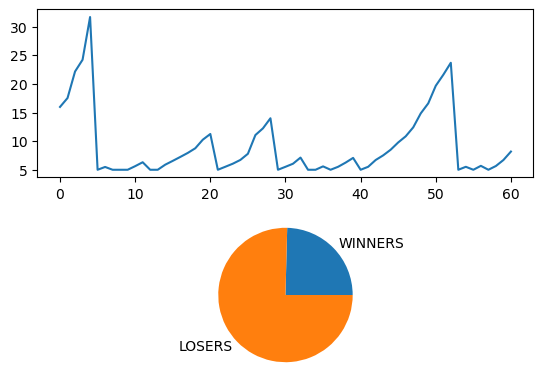

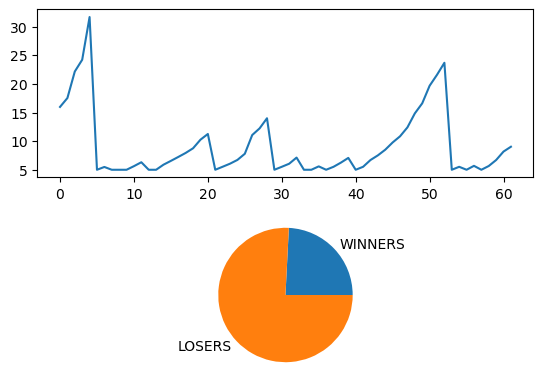

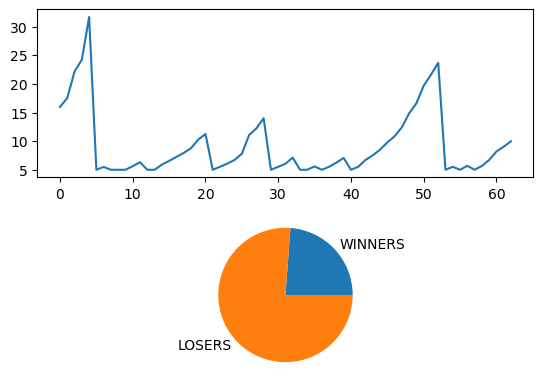

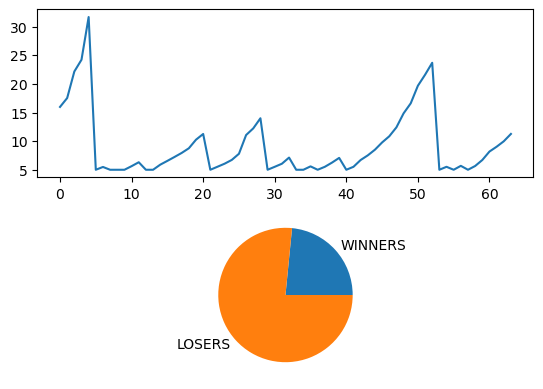

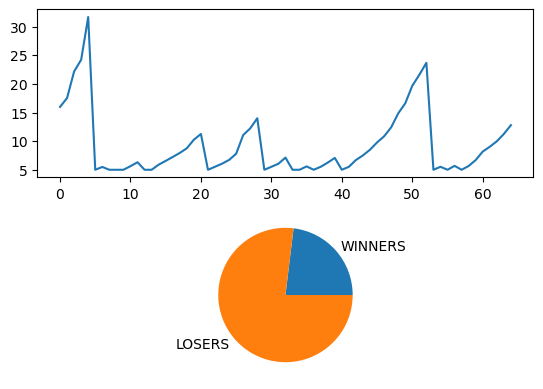

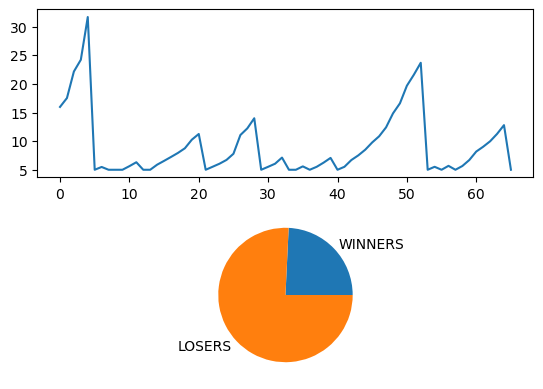

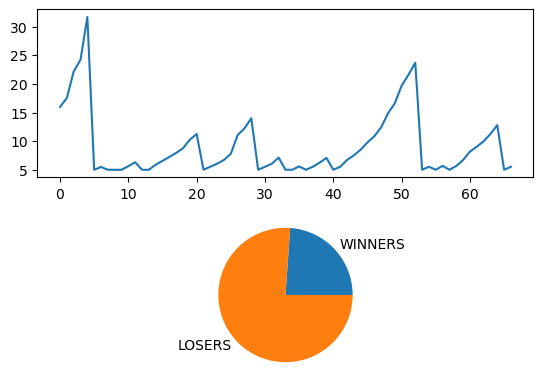

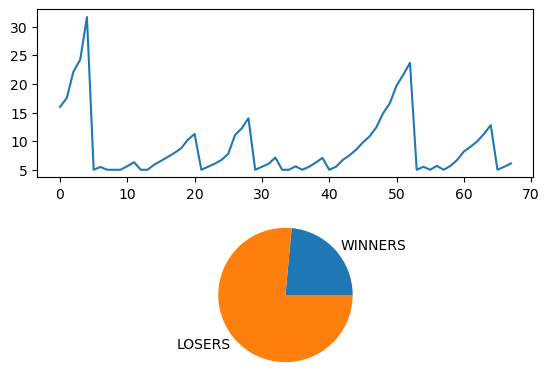

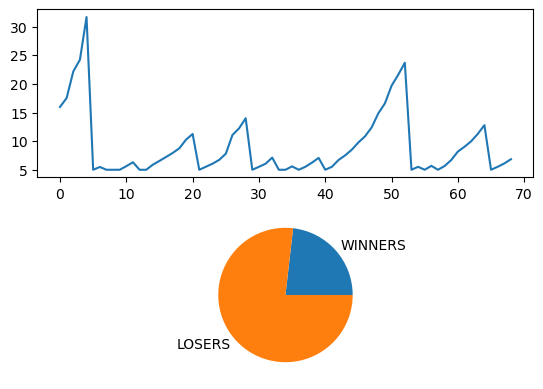

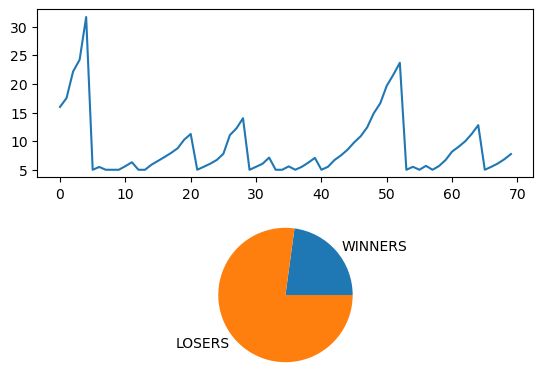

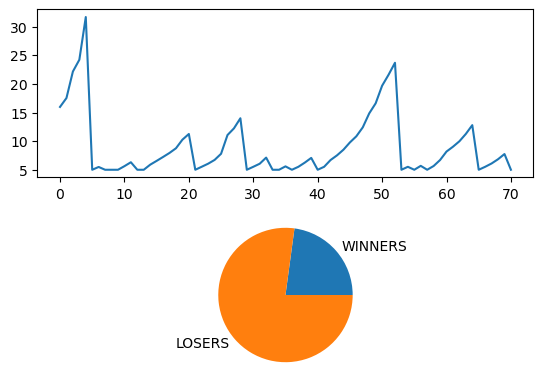

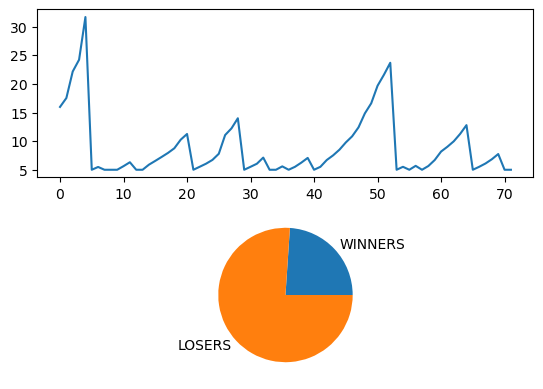

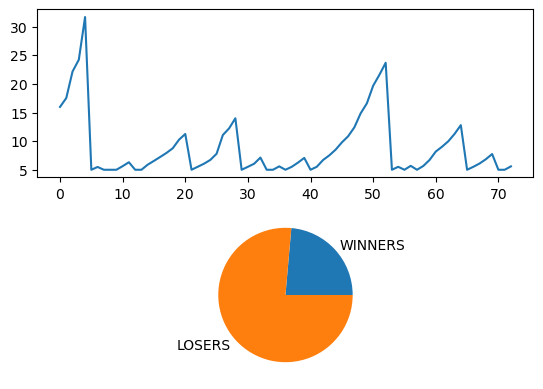

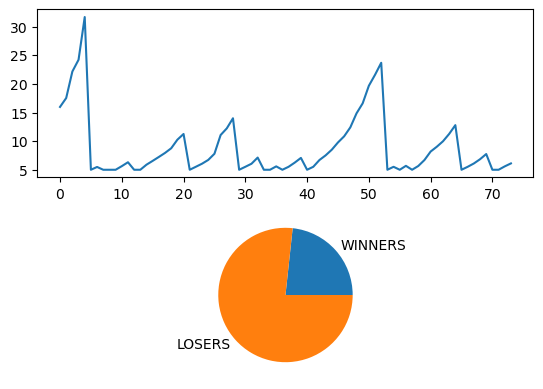

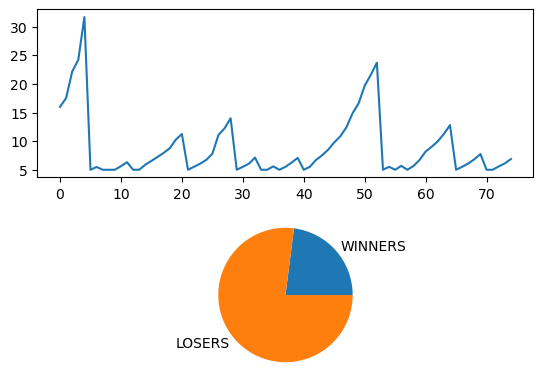

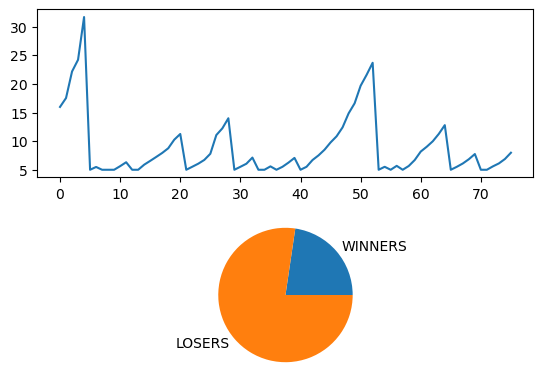

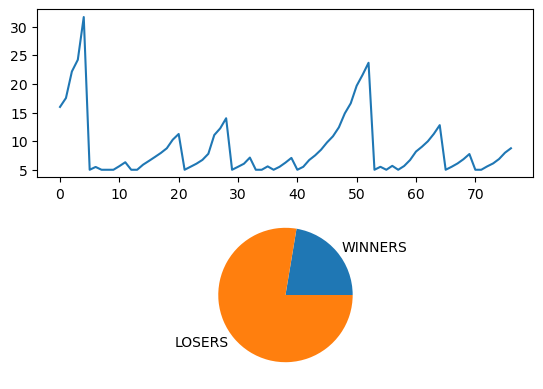

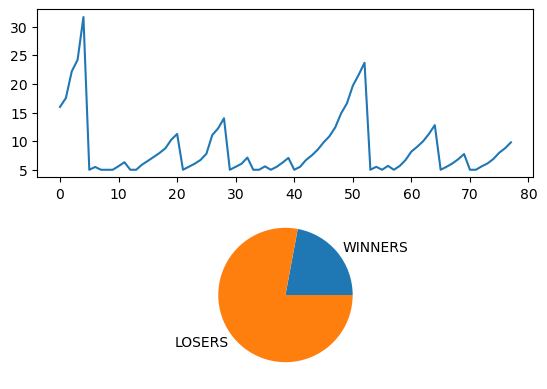

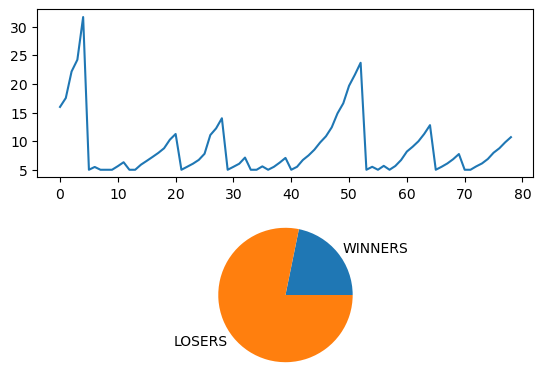

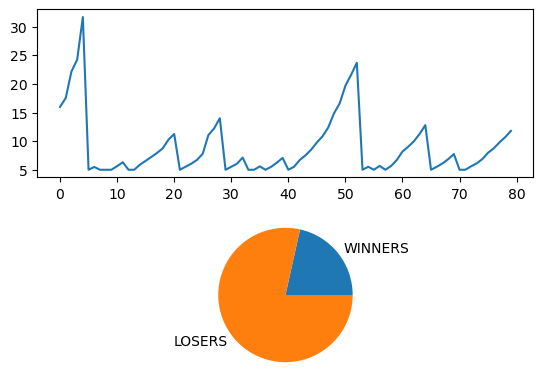

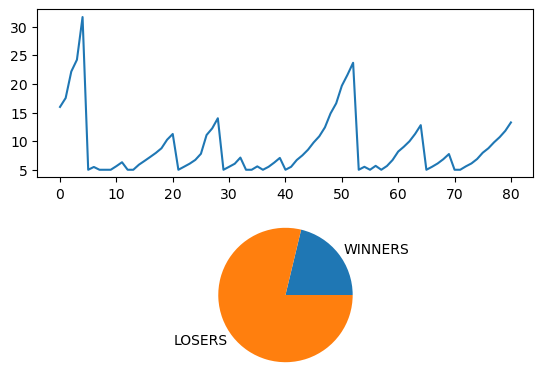

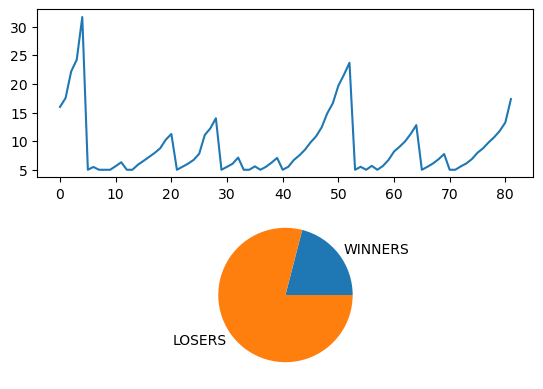

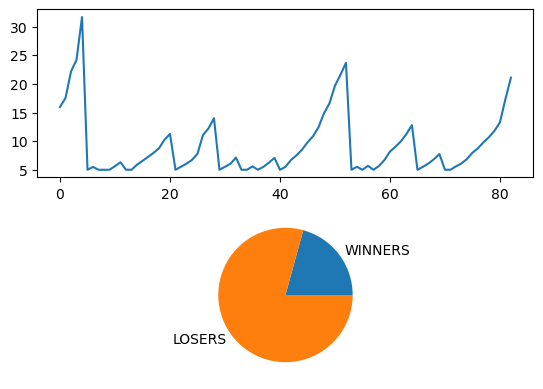

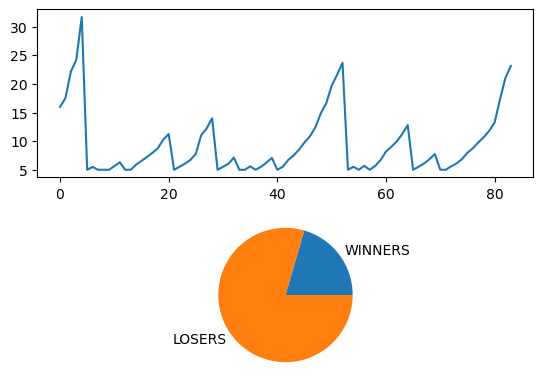

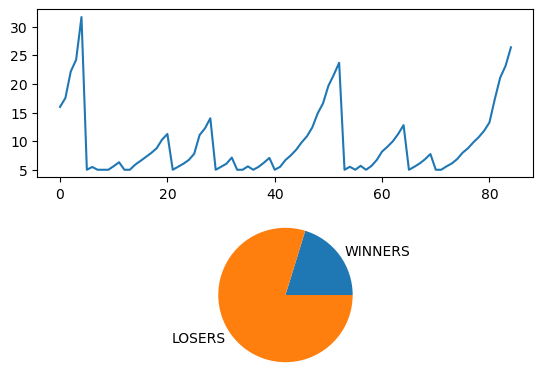

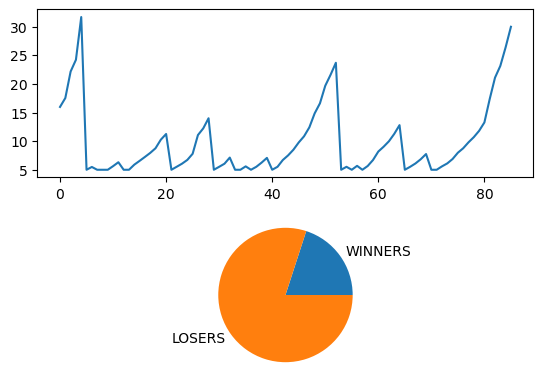

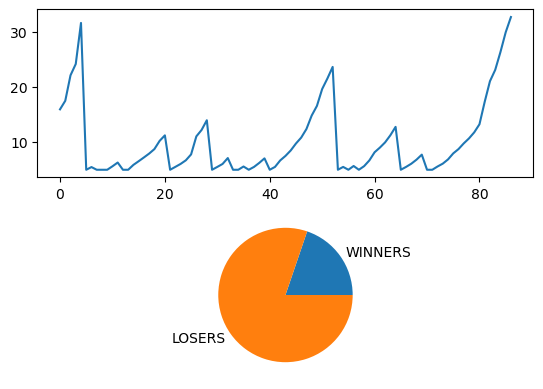

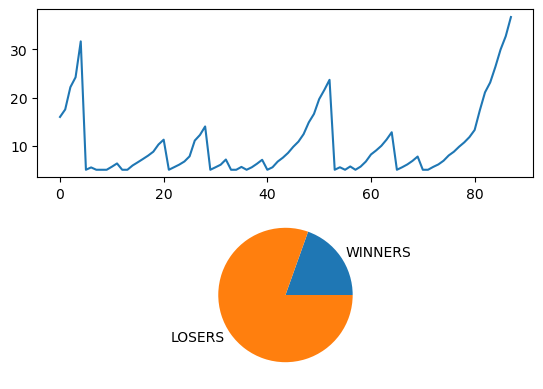

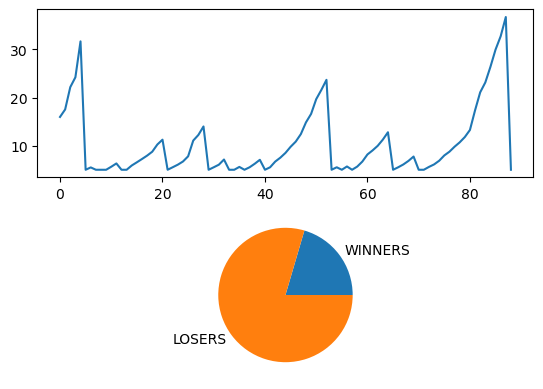

In [1]:
"""
lay runner with minimum return of 'X'
maximum liability of 'Y'
1) call up first race
2) check for outstanding bets
3) check result of outstanding bets
4) update kitty
5) load and assess next race
6) log results
"""

LIABILITY = 13.4
balance = LIABILITY

%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#import required libraries
import datetime
from datetime import date
import requests
import json
import time
from datetime import datetime, timedelta
from time import mktime
import os


pd.options.mode.chained_assignment = None

# balance = 10
bet_perc = .9
minReturn = 10 # changes to liability * .1 in script
maxLiability = 500    

#establish todays date
today = date.today()
print("Today's date:", today)

# Define a list of weekday names
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Index using weekday int value
EVENT_WEEKDAY = days[today.weekday()]
EVENT_DAY = today.day
EVENT_MONTH  = today.month
EVENT_YEAR = today.year

output_file = str(EVENT_YEAR) + str(EVENT_MONTH) + str(EVENT_DAY) + "cumulativeLayStrategyLog_DOGSONLY"

# # Check whether the specified path exists or not
# isExist = os.path.exists(output_dir)



# if not isExist:
  
#     # Create a new directory because it does not exist 
#     os.makedirs(output_dir)
#     print("The new directory is created!")
# else:
#     print('output dir exists')

layStrategyLogdf = pd.DataFrame(columns=['RACE_TYPE', 'RACE_LOCATION', 'BSP', 'LAY_PRICE', 'PPTRADEDVOL',
       'PPMAX', 'PPMIN', 'EVENT_WEEKDAY', 'EVENT_YEAR', 'EVENT_MONTH',
       'EVENT_DAY', 'RACE_NO', 'NO_OF_RUNNERS', 'FAVOURITE', 'RACE_DISTANCE',
       'WIN_LOSE', 'marketId', 'SELECTION_ID', 'MARKET_START_TIME',
       'SELECTION_NAME', 'liability', 'stake', 'outcome', 'balance'])

def bfTickLadder():

    tickIncrements = {
        1.0: 0.01,
        2.0: 0.02,
        3.0: 0.05,
        4.0: 0.1,
        6.0: 0.2,
        10.0: 0.5,
        20.0: 1.0,
        30.0: 2.0,
        50.0: 5.0,
        100.0: 10.0,
        1000.0: 1000,
    }

    ladder = []

    for index, key in enumerate(tickIncrements):

        increment = tickIncrements[key]

        if (index+1) == len(tickIncrements):
            ladder.append(key)
        else:
            key1 = [*tickIncrements][index]
            key2 = [*tickIncrements][index+1]
            steps = (key2 - key1) / increment

            for i in range(int(steps)):
                ladder.append(round(key + i * increment, 2))

    return(ladder)

def bfTickFloor(price, includeIndex=False):

    if 'bfticks' in globals():
        global bfticks
    else:
        bfticks = bfTickLadder()

    ind = [ n for n,i in enumerate(bfticks) if i >= price][0]
    if includeIndex:
        if bfticks[ind]==price:
            return((ind, price))
        else:
            return((ind-1, bfticks[ind-1]))
    else:
        if bfticks[ind]==price:
            return(price)
        else:
            return(bfticks[ind-1])

def bfTickFloorProjectedLayPrice(price, includeIndex=False):
    ### price plus two ticks
    if 'bfticks' in globals():
        global bfticks
    else:
        bfticks = bfTickLadder()

    ind = [ n for n,i in enumerate(bfticks) if i >= price][0]
    if includeIndex:
        if bfticks[ind]==price:
            return((ind, price))
        else:
            return((ind+2, bfticks[ind+2]))
    else:
        if bfticks[ind+2]==price:
            return(price)
        else:
            return(bfticks[ind+2])

def checkMarketResult(marketId, selectionId):
    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    # jsonrpc_req=jsonrpc_req= '{"jsonrpc": "2.0","method": "SportsAPING/v1.0/listRunnerBook","params": {"marketId": "1.226960983","selectionIds": "57563909","priceProjection": {"priceData": ["EX_BEST_OFFERS", "EX_TRADED"]}},"id": 1}'
    jsonrpc_req=jsonrpc_req= '{"jsonrpc": "2.0","method": "SportsAPING/v1.0/listRunnerBook","params": {"marketId": "' + marketId + '", "selectionId": "' + selectionId + '"},"id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)
    status, outcome = results['result'][0]['status'], results['result'][0]['runners'][0]['status']

    return status, outcome

def remainingRacesFn():

    #initialise session_id and app_key    
    session_id = str(resp_json['sessionToken'])
    delay_app_key = '5c7rhSyc4gdhEnyF'
    app_key = 'YELm66PJor6sOwCM'
    
    #establish requests endpoint and header
    endpoint = "https://api.betfair.com/exchange/betting/rest/v1.0/"
    
    header = { 'X-Application' : app_key, 'X-Authentication' : session_id ,'content-type' : 'application/json' }
    start = str(today)+ 'T00:00:00Z' 
    stop = str(today) + 'T23:59:00Z'
    
    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    method = 'SportsAPING/v1.0/listMarketCatalogue'
    marketTypeCodes = 'WIN' 
    inPlayOnly = 'false'
    marketCountries = 'AU'  
    locale = 'en' 
    sort = 'FIRST_TO_START' 
    maxResults = 999
    jsonrpc_req='{"jsonrpc": "2.0", "method": "' + str(method) + '", "params": {"filter": {"eventTypeIds": ["4339"], "marketTypeCodes": ["' + str(marketTypeCodes) + '"], "inPlayOnly":' + str(inPlayOnly) + ', "marketCountries": ["'+ str(marketCountries) + '"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"' + str(locale) + '", "sort":"' + str(sort) + '", "maxResults":"999",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)
    
    return len(results['result'])

def getMarketIds():
    
    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    jsonrpc_req='{"jsonrpc": "2.0", "method": "SportsAPING/v1.0/listMarketCatalogue", "params": {"filter": {"eventTypeIds": ["4339"], "marketTypeCodes": ["WIN"], "inPlayOnly":"False", "marketCountries": ["AU"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"en", "sort":"FIRST_TO_START", "maxResults":"999",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)


    if len(results['result']) == 0:
        print('No Market Data')
        return None

    elif len(results['result']) == 1:
        marketId = results['result'][0]['marketId']
        marketName = results['result'][0]['marketName']
        marketStartTime = results['result'][0]['marketStartTime']
        totalMatched = results['result'][0]['totalMatched']
        
        nextMarketId = None
        nextMarketName = None
        nextMarketStartTime = None
        nextTotalMatched = None
        
        # print('Current Market: ', marketId, marketName, marketStartTime, totalMatched)   
        
        return marketId, marketName, marketStartTime, totalMatched, nextMarketId, nextMarketName, nextMarketStartTime, nextTotalMatched

    if len(results['result']) > 1:
        marketId = results['result'][0]['marketId']
        marketName = results['result'][0]['marketName']
        marketStartTime = results['result'][0]['marketStartTime']
        totalMatched = results['result'][0]['totalMatched']

        nextMarketId = results['result'][1]['marketId']
        nextMarketName = results['result'][1]['marketName']
        nextMarketStartTime = results['result'][1]['marketStartTime']
        nextTotalMatched = results['result'][1]['totalMatched']

        # print('Current Market: ', marketId, marketName, marketStartTime, totalMatched)  
        # print('Current Market', getStartTimeDelay(marketStartTime))
        # print('Next Market: ', nextMarketId, nextMarketName, nextMarketStartTime, nextTotalMatched)
        # print('Next Market', getStartTimeDelay(nextMarketStartTime))

        
        return marketId, marketName, marketStartTime, totalMatched, nextMarketId, nextMarketName, nextMarketStartTime, nextTotalMatched

def getStartTimeDelay(marketStartTime):
    now = time.gmtime()
    now = datetime.fromtimestamp(mktime(now))
    # now = now - timedelta(hours=1) 
    
    market_start_time = marketStartTime[0:-5].replace('T', ' ')
    market_start_time = datetime.strptime(market_start_time, "%Y-%m-%d %H:%M:%S") - timedelta(seconds=1)
    
    time_to_start = market_start_time - now  
    total_seconds = time_to_start.total_seconds()

    # print(f"{total_seconds} seconds to race start time")
    
    return total_seconds

########################################################################################## 

def dailyBalanceRecord():
    
    today = date.today()
    yesterday = date.today() - timedelta(days=1)
    print("Today's date:", today, "Yesterday's date:", yesterday)
    
    # establish start and stop time for requests
    start = str(yesterday)+ 'T00:00:00Z' 
    stop = str(yesterday) + 'T23:59:00Z'
    
    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    jsonrpc_req=jsonrpc_req= '{"jsonrpc": "2.0","method": "SportsAPING/v1.0/listClearedOrders","params": { "settledDateRange": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}, "sort":"' + str(sort) + '", "betStatus": "SETTLED"},"id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)
    
    dailyBalanceRecord = []
    
    for i in results['result']['clearedOrders']:
        dailyBalanceRecord.append(i['profit'])
        # print(i['betOutcome'], i['profit'])
    dailyBalanceRecord = np.flip(np.array(dailyBalanceRecord), 0)
    
    wins = (dailyBalanceRecord > 0).sum()
    losses = (dailyBalanceRecord < 0).sum()
    winRatio = wins/len(dailyBalanceRecord)
    
    # dailyBalanceRecord = np.flip(dailyBalanceRecord, 0)
    plt.plot(dailyBalanceRecord.cumsum())
    plt.show()
    
    print(f"wins: {wins}, losses: {losses}, winRatio: {round(winRatio,2)}")

    return dailyBalanceRecord

def waitingTimer(delay):
    for i in range(int(delay),-1,-1):
        print('...waiting...', i, end = ' \r')
        time.sleep(1)

def assessRace(marketId):
    marketId = marketId
    global balance 
    
    print(marketId)
    # #get market details 
    # marketId, marketName, marketStartTime, totalMatched, nextMarketId, nextMarketName, nextMarketStartTime, nextTotalMatched = getMarketIds()
    
    # ### check and load next marketId
    # url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    # method = 'SportsAPING/v1.0/listEventTypes'
    # jsonrpc_req='{"jsonrpc": "2.0", "method": "' + str(method) + '", "params": {"filter": {"eventTypeIds": ["7", "4339"], "marketTypeCodes": ["' + str(marketTypeCodes) + '"], "inPlayOnly":' + str(inPlayOnly) + ', "marketCountries": ["'+ str(marketCountries) + '"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"' + str(locale) + '", "sort":"' + str(sort) + '", "maxResults":"2",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'
    # response = requests.post(url, data=jsonrpc_req, headers=header)
    # results = json.dumps(json.loads(response.text), indent=3)
    # results = json.loads(results)
    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    method = 'SportsAPING/v1.0/listMarketCatalogue'
    marketTypeCodes = 'WIN' 
    inPlayOnly = 'false'
    marketCountries = 'AU'  
    locale = 'en' 
    sort = 'FIRST_TO_START' 
    maxResults = 999
    jsonrpc_req='{"jsonrpc": "2.0", "method": "' + str(method) + '", "params": {"filter": {"eventTypeIds": ["4339"], "marketTypeCodes": ["' + str(marketTypeCodes) + '"], "inPlayOnly":' + str(inPlayOnly) + ', "marketCountries": ["'+ str(marketCountries) + '"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"' + str(locale) + '", "sort":"' + str(sort) + '", "maxResults":"999",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)

    remainingRaces = len(results['result'])

    for race in results['result']:
        if getStartTimeDelay(race['marketStartTime']) > 0:
            nextMarketId = race['marketId']
            nextMarketName = race['marketName']
            nextMarketStartTime = race['marketStartTime']
            nextTotalMatched = race['totalMatched']
            nextStartTimeDelay = getStartTimeDelay(race['marketStartTime'])
            break

    for race in results['result']:
        if getStartTimeDelay(race['marketStartTime']) > 0:
            marketId = race['marketId']
            marketName = race['marketName']
            marketStartTime = race['marketStartTime']
            totalMatched = race['totalMatched']
            startTimeDelay = getStartTimeDelay(race['marketStartTime'])
            break    
    secondsToStart = getStartTimeDelay(marketStartTime)

    # try:    
    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    
    jsonrpc_req='{"jsonrpc": "2.0","method": "SportsAPING/v1.0/listMarketCatalogue","params": {"filter": {"marketIds": ["' + str(marketId) + '"]},"maxResults": "200","marketProjection": ["COMPETITION","EVENT","EVENT_TYPE","RUNNER_DESCRIPTION","RUNNER_METADATA","MARKET_START_TIME"]},"id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)
    
    print(f"assess {results['result'][0]['event']['venue']} {results['result'][0]['eventType']['name']} race in {secondsToStart-1} seconds")
    
    if secondsToStart-1 > 0:
        waitingTimer(secondsToStart-1)
        # print("...waiting...")
        # time.sleep(secondsToStart)
    
    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    now = time.gmtime()
    now = datetime.fromtimestamp(mktime(now))
    now = now - timedelta(hours=1)
    race_df = pd.DataFrame(columns=['marketId', 
                                    'RACE_TYPE', 
                                    'RACE_LOCATION', 
                                    'BSP', 
                                    'LAY_PRICE',
                                    'PPTRADEDVOL', 
                                    'PPMAX', 
                                    'PPMIN',
                                    'EVENT_WEEKDAY', 
                                    'EVENT_YEAR', 
                                    'EVENT_MONTH', 
                                    'EVENT_DAY', 
                                    'RACE_NO', 
                                    'NO_OF_RUNNERS', 
                                    'FAVOURITE', 
                                    'RACE_DISTANCE',
                                    'WIN_LOSE']) 
    
    jsonrpc_req='{"jsonrpc": "2.0","method": "SportsAPING/v1.0/listMarketCatalogue","params": {"filter": {"marketIds": ["' + str(marketId) + '"]},"maxResults": "200","marketProjection": ["COMPETITION","EVENT","EVENT_TYPE","RUNNER_DESCRIPTION","RUNNER_METADATA","MARKET_START_TIME"]},"id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)
    
    jsonrpc_req=jsonrpc_req= '{"jsonrpc": "2.0","method": "SportsAPING/v1.0/listMarketBook","params": {"marketIds": ["' + str(marketId) + '"],"priceProjection": {"priceData": ["EX_BEST_OFFERS", "EX_TRADED"],"virtualise": "true"}},"id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    
    price_results = json.dumps(json.loads(response.text), indent=3)
    price_results = json.loads(price_results)
    
    print('number of runners ', len(results['result'][0]['runners']))
    
    if price_results['result'][0]['status'] != 'SUSPENDED':
        
        for runner in range(len(results['result'][0]['runners'])):
            if price_results['result'][0]['runners'][runner]['status'] != 'ACTIVE':
                pass
            else:
                runner_data = []
        
                selection_Id = results['result'][0]['runners'][runner]['selectionId']
                SELECTION_NAME = results['result'][0]['runners'][runner]['runnerName'][3:]
        
                event_name = results['result'][0]['marketName'].split(' ', 2)
                RACE_NO = int(event_name[0].strip('R'))
                RACE_DISTANCE = int(event_name[1].strip('m'))
                RACE_TYPE = event_name[2]
                RACE_LOCATION = results['result'][0]['event']['name'].split('(', 1)[0][:-1]
        
                try:
                    BSP = price_results['result'][0]['runners'][runner]['ex']['availableToBack'][0]['price']
                except:
                    BSP = 1000
                
                try:
                    LayPrice = price_results['result'][0]['runners'][runner]['ex']['availableToLay'][0]['price']
                except:
                    LayPrice = 1000
                
                try:
                    PPTRADEDVOL = price_results['result'][0]['runners'][runner]['totalMatched']
                except:
                    PPTRADEDVOL = 0
        
                try:
                    PPMAX = 0
                    PPMIN = 1000
                    for i in range(len(price_results['result'][0]['runners'][runner]['ex']['tradedVolume'])):
                        if price_results['result'][0]['runners'][runner]['ex']['tradedVolume'][i]['price'] > PPMAX:
                            PPMAX = price_results['result'][0]['runners'][runner]['ex']['tradedVolume'][i]['price']
                        if price_results['result'][0]['runners'][runner]['ex']['tradedVolume'][i]['price'] < PPMIN:
                            PPMIN = price_results['result'][0]['runners'][runner]['ex']['tradedVolume'][i]['price']
                except:
                    PPMIN = 0
                    PPMAX = 0   
        
                NO_OF_RUNNERS = len(results['result'][0]['runners'])
                FAVOURITE = 0
                FILL = 0
        
                market_start_time = results['result'][0]['marketStartTime'][0:-5].replace('T', ' ')
                market_start_time = datetime.strptime(market_start_time, "%Y-%m-%d %H:%M:%S")
                market_start_time
        
                last_row = len(race_df)
        
                race_df.at[last_row,'marketId'] = float(marketId)
                race_df.at[last_row,'SELECTION_ID'] = selection_Id
                race_df.at[last_row,'MARKET_START_TIME'] = market_start_time
                race_df.at[last_row,'SELECTION_NAME'] = SELECTION_NAME
                race_df.at[last_row,'EVENT_WEEKDAY'] = EVENT_WEEKDAY
                race_df.at[last_row,'RACE_TYPE'] = RACE_TYPE
                race_df.at[last_row,'BSP'] = BSP
                race_df.at[last_row,'LAY_PRICE'] = LayPrice
                race_df.at[last_row,'PPMIN'] = PPMIN
                race_df.at[last_row,'PPMAX'] = PPMAX
                race_df.at[last_row,'PPTRADEDVOL'] = PPTRADEDVOL
                race_df.at[last_row,'RACE_DISTANCE'] = RACE_DISTANCE
                race_df.at[last_row,'EVENT_YEAR'] = EVENT_YEAR
                race_df.at[last_row,'EVENT_MONTH'] = EVENT_MONTH
                race_df.at[last_row,'EVENT_DAY'] = EVENT_DAY
                race_df.at[last_row,'RACE_NO'] = RACE_NO
                race_df.at[last_row,'NO_OF_RUNNERS'] = NO_OF_RUNNERS
                race_df.at[last_row,'FAVOURITE'] = FAVOURITE
                race_df.at[last_row,'RACE_LOCATION'] = RACE_LOCATION
        
        race_df.sort_values(by=['BSP'], ascending=True, inplace=True)
        race_df['FAVOURITE'] = race_df.groupby(['BSP']).cumcount() + 1
        race_df['FAVOURITE'] = race_df['FAVOURITE'].astype('int64')
        race_df['NO_OF_RUNNERS'] = len(race_df) - len(race_df[race_df['BSP']==1000])
        race_df.sort_values(by='BSP', inplace=True, ascending=False)
        
        betCount = 0
        
        ####get balance
        account_url="https://api.betfair.com/exchange/account/json-rpc/v1"
        jsonrpc_req='{"jsonrpc": "2.0", "method": "AccountAPING/v1.0/getAccountFunds", "id": 15}'
        response = requests.post(account_url, data=jsonrpc_req, headers=header)
        account_balance_results = json.dumps(json.loads(response.text), indent=3)
        account_balance_results = json.loads(account_balance_results)
        realBalance = account_balance_results['result']['availableToBetBalance']
        print(f"realBalance {realBalance}") 
        
        
        ### quit program if balance is less than $10
        if balance <= 10.01:
            print(f"Balance {balance}. Too Low") 
            # quit()
        
    
        # jsonrpc_req = '{"jsonrpc": "2.0", "method": "SportsAPING/v1.0/listCurrentOrders", "params": {"marketIds":["' + str(marketId) + '"],"settledDateRange":{},"betIds":[]}, "id": 1}'# "params": {"betStatus":"SETTLED","settledDateRange":{},"groupBy":"MARKET","betIds":["342772899163"], "id": 1}'
        # jsonrpc_req = '{"jsonrpc": "2.0", "method": "SportsAPING/v1.0/listCurrentOrders", "params": {"settledDateRange":{},"betIds":[]}, "id": 1}'# "params": {"betStatus":"SETTLED","settledDateRange":{},"groupBy":"MARKET","betIds":["342772899163"], "id": 1}'
        jsonrpc_req = '{"jsonrpc": "2.0", "method": "SportsAPING/v1.0/listCurrentOrders", "params": {"settledDateRange":{},"marketIds": ["' + str(marketId) + '"], "betIds":[]}, "id": 1}'# "params": {"betStatus":"SETTLED","settledDateRange":{},"groupBy":"MARKET","betIds":["342772899163"], "id": 1}'
        settledBets_response = requests.post(url, data=jsonrpc_req, headers=header)
        settledBets_results = json.dumps(json.loads(settledBets_response.text), indent=3)
        settledBets_results = json.loads(settledBets_results)
        
        if len(settledBets_results['result']['currentOrders']) == 0:
        
    
            liability = balance
        
            # liability = (balance*bet_perc) 
            # if liability > maxLiability:
            #     liability = maxLiability
            
            minReturn = liability * .1
            
            betsInRace = 0
            
            for index, row in race_df.iterrows():
                if betsInRace == 0:
                    try:
                        layPrice = round(bfTickUp(row['BSP']),2)
                    except:
                        layPrice = round(row['BSP'],2)
                        
                    stake = round(liability/(layPrice -1), 2)



                    if balance > 150:
                        x = 15
                    elif balance > 100:
                        x = 10
                    elif balance > 75:
                        x = 7.5
                    elif balance > 50:
                        x = 5                       
                    else:
                        x = 25
                    

                    
                    if stake > minReturn or stake > x:
                        # print(row['SELECTION_NAME'], balance/(layPrice))
                        betsInRace += 1
            
                        selectionId = row['SELECTION_ID']
                        # stake = round((balance *.5)/(layPrice-1), 0)
                        print(f"balance: {round(balance,2)}, stake: {stake}, liability: {round(liability,2)}, layPrice: {round(layPrice,2)}, Selection name: {row['SELECTION_NAME']} ")
                        nextRow = race_df[race_df['SELECTION_ID'] == selectionId]

                        nextRow.at[nextRow.index[0],'liability'] = liability
                        nextRow.at[nextRow.index[0],'stake'] = stake
                        
        # """
            #### PLACE LIVE BETS            
                        ### raise lay price by 2 ticks
                        layPrice = bfTickFloorProjectedLayPrice(layPrice) 
                        # # jsonrpc_req = '{"jsonrpc": "2.0","method": "SportsAPING/v1.0/placeOrders","params": {"marketId": "1.226411815","instructions": [{"selectionId": "58138391.0","handicap": "0","side": "BACK", "orderType": "LIMIT", "limitOrder": {"size": "2.5", "price": "4", "persistenceType": "LAPSE"}}]},"id": 1}'
                        url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
                        jsonrpc_req = '{"jsonrpc": "2.0","method": "SportsAPING/v1.0/placeOrders","params": {"marketId": "' + str(marketId) + '","instructions": [{"selectionId": "' + str(int(selectionId)) + '","handicap": "0","side": "LAY","orderType": "LIMIT", "limitOrder": {"size": "' + str(stake) + '", "price": "' + str(layPrice) + '", "persistenceType": "MARKET_ON_CLOSE"}}]},"id": 1}'        
                        bet_response = requests.post(url, data=jsonrpc_req, headers=header)
                        bet_results = json.dumps(json.loads(bet_response.text), indent=3)
                        bet_results = json.loads(bet_results)
        
        
                        print(f"Number of Bets in {row['RACE_LOCATION']} race {row['RACE_NO']}: {betCount}")     
                    
                        print(f"Selection name: {row['SELECTION_NAME']} layPrice: {layPrice} ResultsStatus: {bet_results['result']['status']}")#" averageMatchedPrice: {bet_results['result']['instructionReports'][0]['averagePriceMatched']}")
                    
                        print(f"BSP: {BSP}, stake: {stake}, Lay Price {layPrice}, Balance {balance}")
        

    else:
        pass
    
    race_df[['SELECTION_NAME', 'SELECTION_ID', 'BSP', 'LAY_PRICE']]
    
    status, outcome = checkMarketResult(marketId, str(int(selectionId)))
    
    # print(f"balance {balance}") 
    
    ### check result of previous race every 30 seconds until cleared
    counter = 0
    while status != "CLOSED":
        counter += 1
        status, outcome = checkMarketResult(marketId, str(int(selectionId)))
        print(counter, status, outcome, end = '\r')
        if status == "CLOSED":
            print(f"result: {status}, {outcome}, remainingRaces: {remainingRaces-1}")
            if outcome == "LOSER":
                balance +=  (stake * .925)
                if balance > 100:
                    balance -= LIABILITY 
            else:
                balance = 5
            print(f"balance: {balance}")
            # quit()
        else:
            time.sleep(30)

    
    nextRow.at[nextRow.index[0],'outcome'] = outcome
    nextRow.at[nextRow.index[0],'balance'] = balance
    layStrategyLogdf.loc[len(layStrategyLogdf)] = nextRow.iloc[0]
    layStrategyLogdf.to_csv(output_file)
    # print(f"balance {balance}") 
    
    # except:
    #     print(f"...Market {marketId} Failed. Attempting Next Market...")    
    #     pass

    ### check and load next marketId

    # url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    # method = 'SportsAPING/v1.0/listEventTypes'        
    # jsonrpc_req='{"jsonrpc": "2.0", "method": "' + str(method) + '", "params": {"filter": {"eventTypeIds": ["7", "4339"], "marketTypeCodes": ["' + str(marketTypeCodes) + '"], "inPlayOnly":' + str(inPlayOnly) + ', "marketCountries": ["'+ str(marketCountries) + '"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"' + str(locale) + '", "sort":"' + str(sort) + '", "maxResults":"2",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'
    # response = requests.post(url, data=jsonrpc_req, headers=header)
    # results = json.dumps(json.loads(response.text), indent=3)
    # results = json.loads(results)

    # url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    # method = 'SportsAPING/v1.0/listMarketCatalogue'
    # marketTypeCodes = 'WIN' 
    # inPlayOnly = 'false'
    # marketCountries = 'AU'  
    # locale = 'en' 
    # sort = 'FIRST_TO_START' 
    # maxResults = 999

    # jsonrpc_req='{"jsonrpc": "2.0", "method": "' + str(method) + '", "params": {"filter": {"eventTypeIds": ["7", "4339"], "marketTypeCodes": ["' + str(marketTypeCodes) + '"], "inPlayOnly":' + str(inPlayOnly) + ', "marketCountries": ["'+ str(marketCountries) + '"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"' + str(locale) + '", "sort":"' + str(sort) + '", "maxResults":"' + str(maxResults) + '",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'
    # response = requests.post(url, data=jsonrpc_req, headers=header)
    # results = json.dumps(json.loads(response.text), indent=3)
    # results = json.loads(results)
    
    # for race in results['result']:
    #     if getStartTimeDelay(race['marketStartTime']) > 0:
    #         nextMarketId = race['marketId']
    #         nextMarketName = race['marketName']
    #         nextMarketStartTime = race['marketStartTime']
    #         nextTotalMatched = race['totalMatched']
    #         nextStartTimeDelay = getStartTimeDelay(race['marketStartTime'])
    #         break

    url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
    method = 'SportsAPING/v1.0/listMarketCatalogue'
    marketTypeCodes = 'WIN' 
    inPlayOnly = 'false'
    marketCountries = 'AU'  
    locale = 'en' 
    sort = 'FIRST_TO_START' 
    maxResults = 999
    jsonrpc_req='{"jsonrpc": "2.0", "method": "' + str(method) + '", "params": {"filter": {"eventTypeIds": ["4339"], "marketTypeCodes": ["' + str(marketTypeCodes) + '"], "inPlayOnly":' + str(inPlayOnly) + ', "marketCountries": ["'+ str(marketCountries) + '"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"' + str(locale) + '", "sort":"' + str(sort) + '", "maxResults":"999",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'
    response = requests.post(url, data=jsonrpc_req, headers=header)
    results = json.dumps(json.loads(response.text), indent=3)
    results = json.loads(results)

    for race in results['result']:
        if getStartTimeDelay(race['marketStartTime']) > 0:
            nextMarketId = race['marketId']
            nextMarketName = race['marketName']
            nextMarketStartTime = race['marketStartTime']
            nextTotalMatched = race['totalMatched']
            nextStartTimeDelay = getStartTimeDelay(race['marketStartTime'])
            break

    print(f"nextMarketId: {nextMarketId}, nextMarketName {nextMarketName}, nextMarketStartTime{nextMarketStartTime}, nextTotalMatched {round(nextTotalMatched,2)}, nextStartTimeDelay {round(nextStartTimeDelay, 2)}")
    
    fig, (ax1, ax2) = plt.subplots(2, 1)
    ax1.plot(layStrategyLogdf['balance'])
    ax2.pie([sum(layStrategyLogdf['outcome'] == 'WINNER'), sum(layStrategyLogdf['outcome'] == 'LOSER')], labels = ['WINNERS', 'LOSERS'])
    plt.show
    
    print(f"{round((layStrategyLogdf['balance'].iloc[-1]-11.95)/11.95,2)}% return, {round(layStrategyLogdf['balance'].max(),2)} balance max, {round(layStrategyLogdf['balance'].min(),2)} balance min")
    
    while remainingRacesFn() > 0:
        if remainingRacesFn() == 0:
            break
        try: 
            assessRace(marketId)
        except:
            print(f"Error in market {marketId}...{remainingRacesFn()} races remaining today...reattempting in {waitingTimer(30)} seconds")
            time.sleep(30)
            pass
    
    print(f"...{len(remainingRacesFn())} races remaining today..." )
##########################################################################################    

#establish connection with betfair api
payload = 'username=XXXX&password=XXXX'
headers = {'X-Application': 'SomeKey', 'Content-Type': 'application/x-www-form-urlencoded'}

cert_path = #certPath
key_path = #keyPath

resp = requests.post('https://identitysso-cert.betfair.com/api/certlogin', data=payload, cert=(cert_path, key_path), headers=headers)
 
if resp.status_code == 200:
    resp_json = resp.json()
    print(resp_json['loginStatus'])
    print(resp_json['sessionToken'])
else:
    print("Request failed.")

#initialise session_id and app_key    
session_id = str(resp_json['sessionToken'])
app_key = #appkey

#establish requests endpoint and header
endpoint = "https://api.betfair.com/exchange/betting/rest/v1.0/"

header = { 'X-Application' : app_key, 'X-Authentication' : session_id ,'content-type' : 'application/json' }

#establish todays date
today = date.today()

# Define a list of weekday names
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Index using weekday int value
EVENT_WEEKDAY = days[today.weekday()]
EVENT_DAY = today.day
EVENT_MONTH  = today.month
EVENT_YEAR = today.year

today = date.today()
print("Today's date:", today)

# establish start and stop time for requests
start = str(today)+ 'T00:00:00Z' 
stop = str(today) + 'T23:59:00Z'

url = "https://api.betfair.com/exchange/betting/json-rpc/v1"
###Load todays WIN markets

method = 'SportsAPING/v1.0/listMarketCatalogue'
eventTypeIds = 7
marketTypeCodes = 'WIN' 
inPlayOnly = 'false'
marketCountries = 'AU'  
locale = 'en' 
sort = 'FIRST_TO_START' 
maxResults = 999

jsonrpc_req='{"jsonrpc": "2.0", "method": "' + str(method) + '", "params": {"filter": {"eventTypeIds": ["4339"], "marketTypeCodes": ["' + str(marketTypeCodes) + '"], "inPlayOnly":' + str(inPlayOnly) + ', "marketCountries": ["'+ str(marketCountries) + '"], "marketStartTime": {"from":"' + str(start) + '" ,"to": "' + str(stop) + '"}}, "locale":"' + str(locale) + '", "sort":"' + str(sort) + '", "maxResults":"' + str(maxResults) + '",  "marketProjection": ["MARKET_START_TIME"]}, "id": 1}'

response = requests.post(url, data=jsonrpc_req, headers=header)

results = json.dumps(json.loads(response.text), indent=3)

results = json.loads(results)


marketId = results['result'][0]['marketId']
marketName = results['result'][0]['marketName']
marketStartTime = results['result'][0]['marketStartTime']
totalMatched = results['result'][0]['totalMatched']

print('First Market: ', marketId, marketName, marketStartTime, totalMatched)
print(f"Total number of markets today {len(results['result'])}")


#### Start Daily Chain Reaction

marketId, marketName, marketStartTime, totalMatched, nextMarketId, nextMarketName, nextMarketStartTime, nextTotalMatched = getMarketIds()

dailyBalanceRecord = dailyBalanceRecord()

assessRace(marketId)


In [ ]:
fibSeq = [1, 1]
for i in range(2,102,1):
    fibSeq.append(fibSeq[i-1] + fibSeq[i-2])
fibSeq

In [ ]:
martSeq = [1]
for i in range(1,101,1):
    martSeq.append(martSeq[i-1]*2)
martSeq